# Bulk Hi-C — contact maps, compartments and TADs

Hi-C measures the 3D folding of the genome: how often any two loci contact each other. `ov.epi`
wraps epione's Hi-C analysis (`ov.epi.bulk.hic.*`, built on `cooler` + `cooltools`) so the standard
analyses — contact matrices, the distance-decay curve P(s), A/B compartments, and topologically
associating domains (TADs) — are a few calls.

**Data.** This tutorial uses a balanced Drosophila S2 `.cool` (10 kb bins) from the HiCExplorer /
Galaxy Hi-C training set. Point the `COOL` path below at your own balanced `.cool` /
`.mcool::/resolutions/N`; the upstream FASTQ→pairs→cool steps live in `ov.epi.upstream`
(`pairs_from_bam`, `pairs_to_cool`). Everything downstream is generic to any balanced cooler.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cooler

import omicverse as ov
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

DATA = pathlib.Path('/scratch/users/steorra/data/drosophila-hic')
COOL = str(DATA / 'drosophila.cool')
FASTA = str(DATA / 'dm3_genome.fasta')   # used only to GC-phase the compartments

hic = ov.epi.bulk.hic
clr = cooler.Cooler(COOL)
print('resolution:', clr.binsize, 'bp | bins:', clr.info['nbins'], '| chroms:', clr.chromnames[:6])

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1
resolution: 10000 bp | bins: 16880 | chroms: ['chr2L', 'chr2LHet', 'chr2R', 'chr2RHet', 'chr3L', 'chr3LHet']


## 1 · Contact matrices

`ov.epi.bulk.hic.plot_contact_matrix` reads the cooler directly and renders an ICE-balanced,
log-scaled heatmap for any region — a whole chromosome arm, then a 3 Mb zoom where TAD structure
appears as on-diagonal blocks.

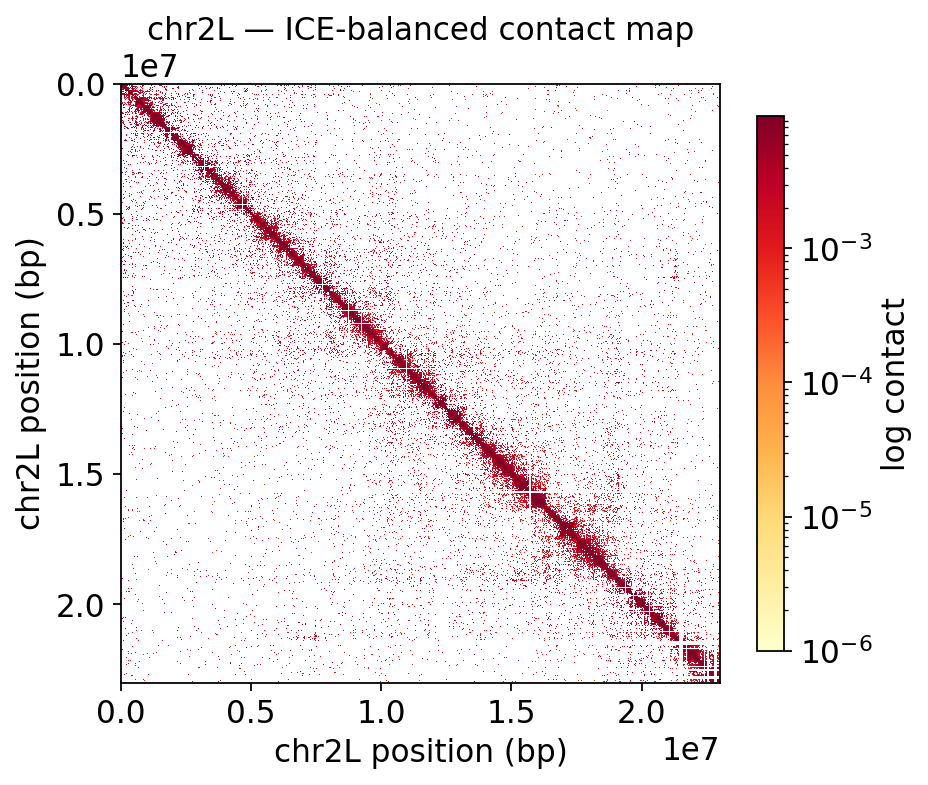

In [2]:
fig, ax, _ = hic.plot_contact_matrix(
    COOL, region='chr2L', balance=True, log=True,
    figsize=(6, 5.5), title='chr2L — ICE-balanced contact map')
plt.show()

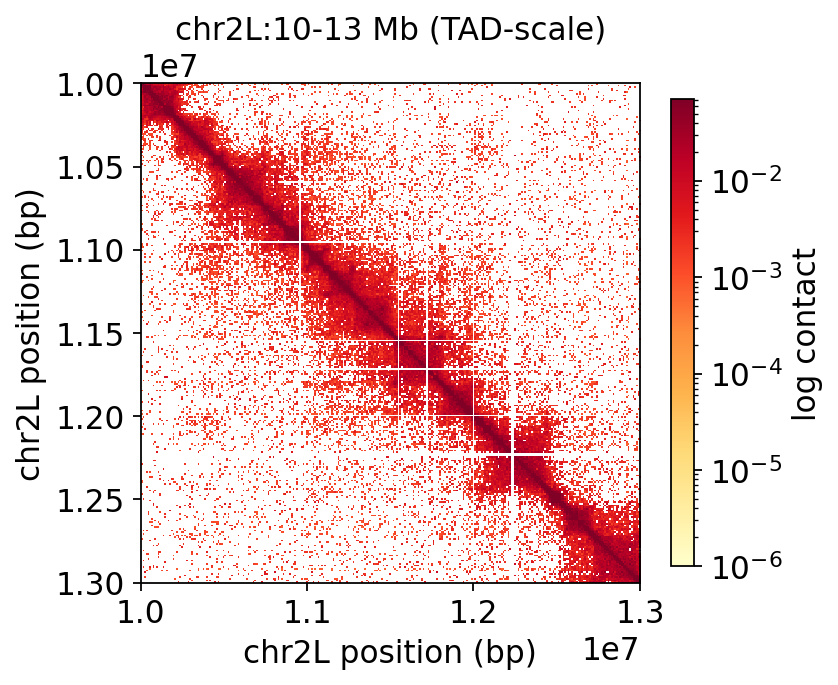

In [3]:
fig, ax, _ = hic.plot_contact_matrix(
    COOL, region='chr2L:10_000_000-13_000_000', balance=True, log=True,
    figsize=(5, 4.8), title='chr2L:10-13 Mb (TAD-scale)')
plt.show()

## 2 · Distance decay P(s)

Contact frequency falls off with genomic distance — the P(s) curve. Its shape is a global summary
of chromatin folding and a key QC for any Hi-C library.

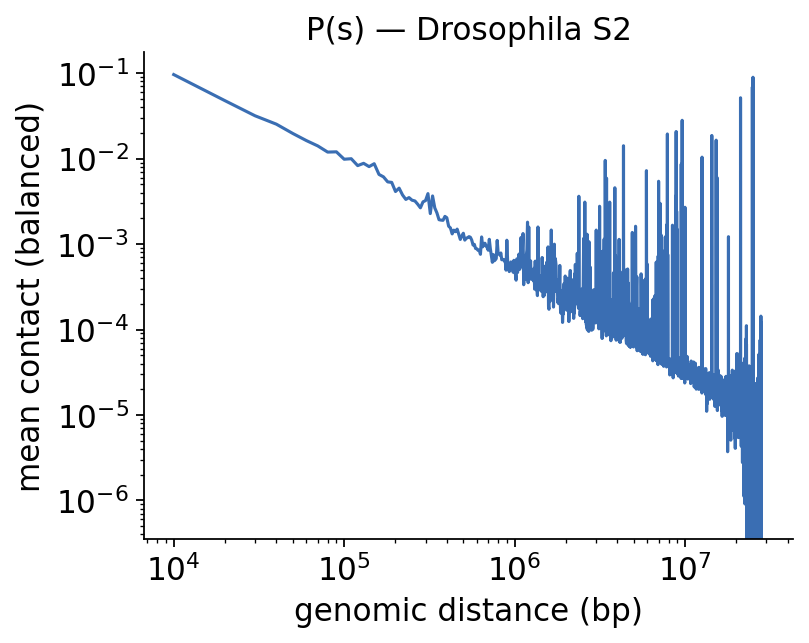

,chrom,offset_bin,distance_bp,mean_contact,n_pairs
0,chr2L,0,0,0.263320,2222
1,chr2L,1,10000,0.120140,2177
2,chr2L,2,20000,0.056927,2167
3,chr2L,3,30000,0.037639,2168
4,chr2L,4,40000,0.028203,2164


In [4]:
fig, ax, decay = hic.plot_decay_curve(COOL, balance=True, figsize=(5.2, 4),
                                      title='P(s) — Drosophila S2')
plt.show()
decay.head()

## 3 · A/B compartments

At the megabase scale chromatin separates into an active **A** and inactive **B** compartment.
`ov.epi.bulk.hic.compartments` computes the eigenvector decomposition of the observed/expected
matrix; GC content (from the FASTA) is used to sign E1 so that **positive E1 = A**.

   chrom  start    end        E1
0  chr2L      0  10000       NaN
1  chr2L  10000  20000  3.049649
2  chr2L  20000  30000  1.300753
3  chr2L  30000  40000  0.920896
4  chr2L  40000  50000  0.490555


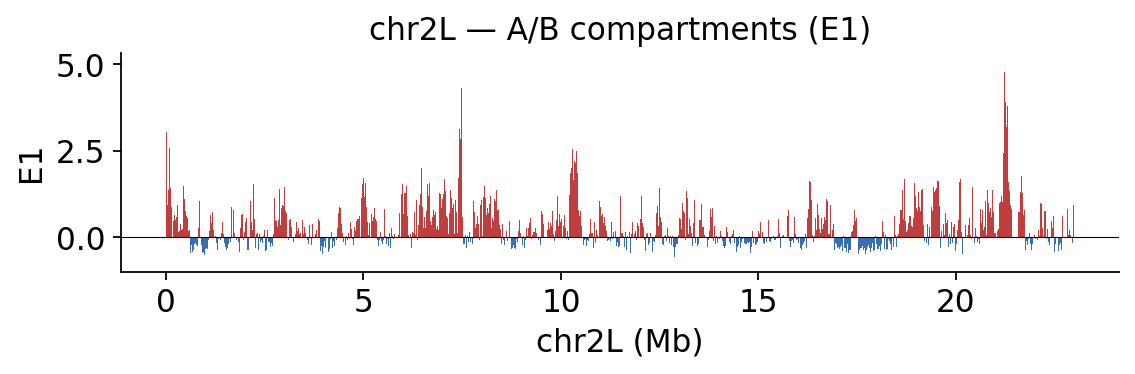

In [5]:
comp = hic.compartments(COOL, chromosomes=['chr2L', 'chr2R', 'chr3L', 'chr3R'],
                        fasta_path=FASTA)
print(comp[['chrom', 'start', 'end', 'E1']].head())

fig, ax = hic.plot_compartments(comp, chromosome='chr2L', track_column='E1',
                                title='chr2L — A/B compartments (E1)')
plt.show()

### Saddle plot

A saddle plot summarises compartmentalisation strength: binning the O/E matrix by compartment
eigenvalue, A–A and B–B contacts (corners) are enriched over A–B (off-diagonal).

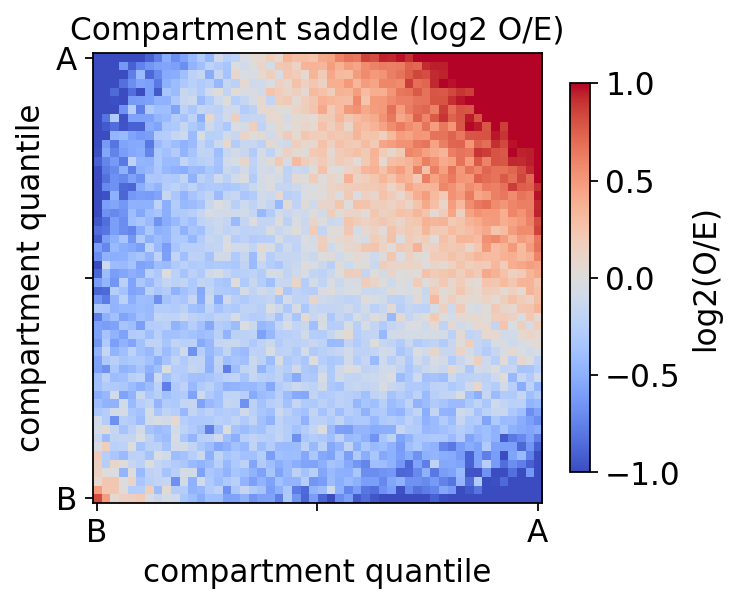

In [6]:
saddle = hic.saddle(COOL, comp, chromosomes=['chr2L', 'chr2R', 'chr3L', 'chr3R'])
mat, edges = saddle[0], saddle[1]   # (saddle matrix, bin edges, count matrix)
fig, ax, _ = hic.plot_saddle(mat, edges=edges, title='Compartment saddle (log2 O/E)')
plt.show()

## 4 · Insulation and TAD boundaries

At finer scale the genome folds into TADs. The diamond **insulation score**
(`ov.epi.bulk.hic.insulation`) dips at domain boundaries; `tad_boundaries` calls them.

INFO:root:fallback to serial implementation.


insulation bins: 2302 | TAD boundaries called: 96


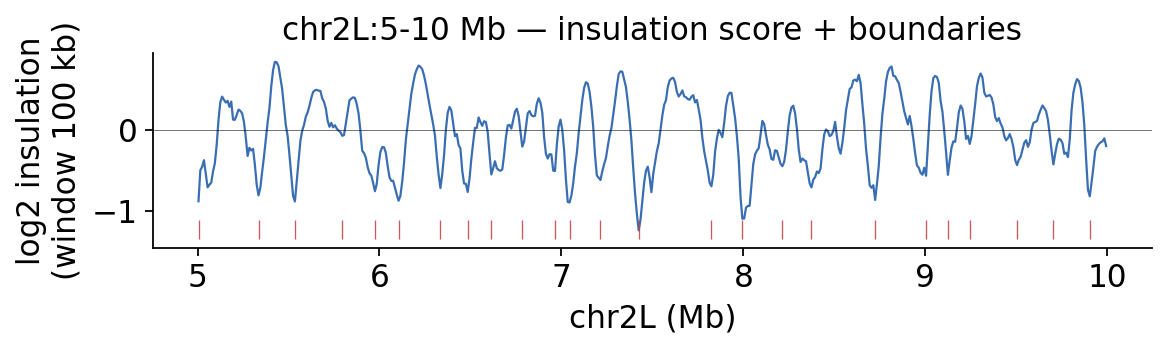

In [7]:
ins = hic.insulation(COOL, window_bp=100_000, chromosomes=['chr2L'], ignore_diags=2)
bounds = hic.tad_boundaries(ins)
print('insulation bins:', len(ins), '| TAD boundaries called:', len(bounds))

fig, ax = hic.plot_insulation(
    ins, chromosome='chr2L', region_start=5_000_000, region_end=10_000_000,
    title='chr2L:5-10 Mb — insulation score + boundaries')
plt.show()

## Summary

| stage | function |
|---|---|
| contact matrix | `ov.epi.bulk.hic.plot_contact_matrix` |
| distance decay P(s) | `ov.epi.bulk.hic.plot_decay_curve` |
| A/B compartments | `ov.epi.bulk.hic.compartments` + `plot_compartments` / `saddle` |
| TAD insulation | `ov.epi.bulk.hic.insulation` + `tad_boundaries` + `plot_insulation` |

All operate directly on a `cooler` file, so the same calls work on any organism and resolution.
The companion tutorial covers **single-cell** Hi-C.